# Pancreas downstream analysis after DFFP scoring

This notebook is a focused guide to biological analyses performed **after** the
supervised topology, ordering, velocity graph, anchor diagnostics, and
Discounted Future-Fate Propagation (DFFP) model have been accepted.

It distinguishes three questions:

1. Which genes are expressed along the fitted trajectory?
2. Which genes are associated with variation in a DFFP outcome?
3. Which genes mark annotated terminal identities versus the root?

These are descriptive or associative analyses. They do not by themselves
establish causal lineage drivers.

> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and reproducibility


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/pancreas_downstream")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


## 2. Load pancreas and fit dynamical RNA velocity

Neighbors, moments, kinetic fitting, velocity, and the velocity graph are computed
in the original PCA/expression manifold. The supervised star is not used to create
neighborhoods or refit velocity.

This tutorial deliberately starts from the public dataset and recomputes the
velocity model. No pre-existing scCS cache is assumed. Dynamical fitting can
take several minutes, but showing the complete preparation makes every analysis
step reproducible for a first-time user.



In [2]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [3]:
RECOVER_DYNAMICS_MAX_ITER = 20

# Load the public scVelo pancreas dataset.
adata = scv.datasets.pancreas()
adata.var_names_make_unique()

# Fit RNA velocity in the original expression/PCA manifold.
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
)
clear_velocity_outputs(adata, clear_dynamics=True)

# Dynamical velocity is used because the pancreas dataset contains several
# kinetic regimes and non-monotonic terminal trajectories.
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
scv.tl.terminal_states(adata)
scv.tl.latent_time(
    adata,
    vkey="velocity",
    root_key="root_cells",
    end_key="end_points",
)
scv.tl.velocity_pseudotime(adata, vkey="velocity")

print(adata)
display(adata.obs["clusters"].astype(str).value_counts().to_frame("n_cells"))

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:13)
computing moments based on connectivities
    finished (0:00:03)
recovering dynamics (using 1/24 cores)


  0%|          | 0/2722 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=93037) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:26:34)
computing velocities
    finished (0:00:09)
computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=93037) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:14)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00)
computing latent time using root_cells, end_points as prior
    finished (0:00:03)
AnnData object with n_obs × n_vars = 3696 × 7197
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'highly_variable_genes', 'gene_count_corr', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap'


,n_cells
clusters,
Ductal,916
Ngn3 high EP,642
Pre-endocrine,592
Beta,591
Alpha,481
Ngn3 low EP,262
Epsilon,142
Delta,70


## 3. Inspect native annotations, ordering candidates, and the velocity field


latent_time                               velocity_pseudotime  \
                    count    median       min       max               count   
clusters                                                                      
Ngn3 high EP          642  0.538150  0.197135  0.668318                 642   
Pre-endocrine         592  0.719086  0.544826  0.767974                 592   
Beta                  591  0.728306  0.690814  1.000000                 591   
Alpha                 481  0.745250  0.704222  0.797031                 481   
Delta                  70  0.785738  0.693870  0.841107                  70   
Epsilon               142  0.740098  0.697535  0.758869                 142   

                                             
                 median       min       max  
clusters                                     
Ngn3 high EP   0.439079  0.116273  0.632564  
Pre-endocrine  0.814839  0.497939  0.914136  
Beta           0.883505  0.835416  1.000000  
Alpha          0.909996  0.830502  0.920302  
Delta          0.918165  0.904303  0.926678  
Epsilon        0.908112  0.863491  0.913667

computing velocity embedding
    finished (0:00:00)


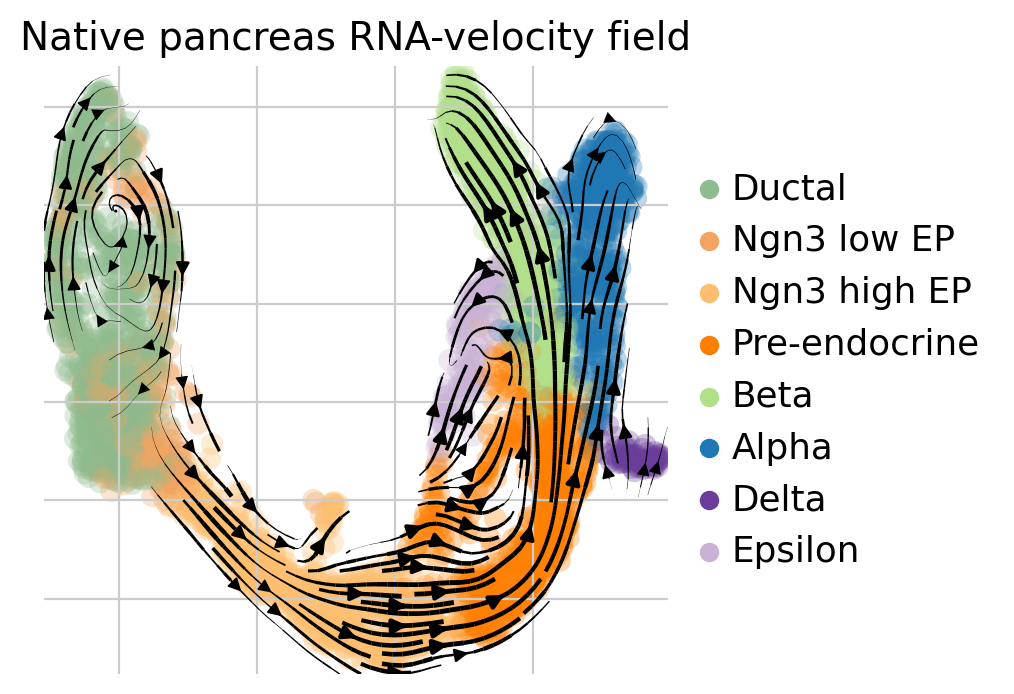

In [4]:
selected_labels = [
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]
selected_mask_full = adata.obs["clusters"].astype(str).isin(selected_labels)
ordering_columns = [key for key in ("latent_time", "velocity_pseudotime") if key in adata.obs]
display(
    adata.obs.loc[selected_mask_full, ["clusters", *ordering_columns]]
    .groupby("clusters", observed=True)
    .agg(["count", "median", "min", "max"])
)

scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="clusters",
    legend_loc="right margin",
    title="Native pancreas RNA-velocity field",
)

## 4. Define the supervised furcation and run preflight diagnostics

The incoming path contains both `Ngn3 high EP` and `Pre-endocrine` because the
earlier progenitor state is required to represent the complete approach to the
endocrine furcation. Dynamical latent time is used for the scientific ordering.


In [5]:
ROOT = ("Ngn3 high EP", "Pre-endocrine")
FATES = ["Alpha", "Beta", "Delta", "Epsilon"]
ORDERING_KEY = "latent_time"

scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="clusters",
)
preflight = scorer.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()

scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,2518.0
1,info,root_cells,Root population contains 1234 cells.,1234.0
2,info,terminal_Alpha,Terminal 'Alpha' contains 481 cells.,481.0
3,info,terminal_Beta,Terminal 'Beta' contains 591 cells.,591.0
4,info,terminal_Delta,Terminal 'Delta' contains 70 cells.,70.0
5,info,terminal_Epsilon,Terminal 'Epsilon' contains 142 cells.,142.0
6,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.0
7,info,ordering_resolution,Root ordering has 1234 unique values across 12...,1.0
8,info,velocity_available,Velocity information is available.,NaN


[scCS] Scientific star built for 2518 cells in 4 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).


## 5. Fit the primary discounted future-fate model


In [6]:
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
    "committed_reach_threshold": 0.25,
    "committed_specificity_threshold": 0.25,
}

scorer.fit(
    scoring_mode="future_fate",
    future_fate_options=FUTURE_OPTIONS,
)
result = scorer.score(write_to_adata=True)

display(pd.Series(result.summary(), name="value").to_frame())
anchor_diagnostics = result.anchor_diagnostics_frame()
display(anchor_diagnostics)
anchor_diagnostics.to_csv(OUTPUT_DIR / "anchor_diagnostics.csv", index=False)

scCS FutureFateScoreResult
  Furcation: root -> ['Alpha', 'Beta', 'Delta', 'Epsilon']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 2518 selected; 1234 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.624
  Root mean future-fate entropy: 0.597
  Root mean future-fate specificity: 0.403
  Root mean reach-supported specificity: 0.254
  Root mean unresolved probability: 0.376
  Root mean signed progression: 0.041
  Root future-fate composition: Alpha=0.291, Beta=0.630, Delta=0.000, Epsilon=0.079
  Solver: direct; iterations=1; residual=1.927e-15
scCS FutureFateScoreResult
  Furcation: root -> ['Alpha', 'Beta', 'Delta', 'Epsilon']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 2518 selected; 1234 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.624
  Root mean future-fate entropy: 0.597
  Root mean future-fate specificity: 0.403
  Root mean reach-supported specificity: 0.254
  Root mean unresolved probability: 0.376
  Root mean signed progre

,value
0,scCS FutureFateScoreResult\n Furcation: root ...


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Alpha,49,0.998604,0.000101,0.001295,0.0,-0.039809,0.000000
1,Beta,60,1.000000,0.000000,0.000000,0.0,-0.009623,0.033333
2,Delta,10,0.857701,0.000722,0.141577,0.0,-0.042991,0.000000
3,Epsilon,15,0.686047,0.198733,0.115220,0.0,-0.098604,0.000000


## 6. Downstream-analysis checklist

Before screening genes, verify that the primary result is numerically stable and
biologically interpretable. The table below records the key DFFP quantities and
anchor diagnostics that should accompany every downstream analysis.

In [7]:
summary_table = pd.DataFrame(
    {
        "cell_id": result.cell_ids,
        "population": np.where(
            result.root_mask,
            "root",
            result.embedding.terminal_names.astype(str),
        ),
        "DFR": result.discounted_fate_reach,
        "FFS": result.future_fate_specificity,
        "RC": result.resolved_commitment,
        "UFP": result.unresolved_future_probability,
        "SOF": result.signed_ordering_flux,
    }
)
for fate_index, fate in enumerate(result.fate_names):
    summary_table[f"CFA:{fate}"] = result.conditional_fate_affinity[:, fate_index]
display(summary_table.describe(include="all").T)
display(result.anchor_diagnostics_frame())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cell_id,2518,2518,AAACCTGAGAGGGATA,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population,2518,5,root,1234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DFR,2518.0,NaN,NaN,NaN,0.681311,0.120331,0.207807,0.610795,0.646416,0.757218,1.0
FFS,2518.0,NaN,NaN,NaN,0.573098,0.258765,0.202401,0.388979,0.402197,0.795657,1.0
RC,2518.0,NaN,NaN,NaN,0.415288,0.260153,0.121476,0.235194,0.258604,0.575375,1.0
UFP,2518.0,NaN,NaN,NaN,0.318689,0.120331,0.0,0.242782,0.353584,0.389205,0.792193
SOF,2518.0,NaN,NaN,NaN,0.040804,0.109793,-0.333231,-0.00598,0.023918,0.083306,0.516719
CFA:Alpha,2518.0,NaN,NaN,NaN,0.302031,0.267297,0.0,0.088344,0.305749,0.311221,1.0
CFA:Beta,2518.0,NaN,NaN,NaN,0.591167,0.309288,0.0,0.41709,0.622889,0.82202,1.0
CFA:Delta,2518.0,NaN,NaN,NaN,0.005288,0.063794,0.0,0.000044,0.000214,0.000223,1.0


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Alpha,49,0.998604,0.000101,0.001295,0.0,-0.039809,0.000000
1,Beta,60,1.000000,0.000000,0.000000,0.0,-0.009623,0.033333
2,Delta,10,0.857701,0.000722,0.141577,0.0,-0.042991,0.000000
3,Epsilon,15,0.686047,0.198733,0.115220,0.0,-0.098604,0.000000


## 7. Resolve and visualize known biological markers

Gene symbols are resolved case-insensitively because public datasets can use
mouse-style capitalization. Missing genes are reported rather than silently
ignored.

In [8]:
marker_candidates = {
    "progenitor": ["Neurog3", "Neurod1", "Insm1", "Pax4"],
    "Alpha": ["Gcg", "Mafb", "Arx"],
    "Beta": ["Ins1", "Ins2", "Iapp", "Pdx1", "Nkx6-1", "Mafa"],
    "Delta": ["Sst", "Hhex"],
    "Epsilon": ["Ghrl"],
    "secretory": ["Chga", "Chgb", "Pcsk1", "Pcsk2", "Scg5"],
}
resolved_groups = {}
missing_groups = {}
for group, candidates in marker_candidates.items():
    resolved, missing = resolve_present_genes(adata, candidates)
    resolved_groups[group] = resolved
    missing_groups[group] = missing

display(
    pd.DataFrame(
        {
            "resolved": {key: ", ".join(value) for key, value in resolved_groups.items()},
            "missing": {key: ", ".join(value) for key, value in missing_groups.items()},
        }
    )
)
markers = list(dict.fromkeys(gene for genes in resolved_groups.values() for gene in genes))

,resolved,missing
progenitor,"Neurog3, Neurod1, Pax4",Insm1
Alpha,"Gcg, Arx",Mafb
Beta,"Ins1, Ins2, Iapp, Pdx1, Nkx6-1",Mafa
Delta,"Sst, Hhex",
Epsilon,Ghrl,
secretory,"Chga, Chgb, Pcsk1, Pcsk2, Scg5",


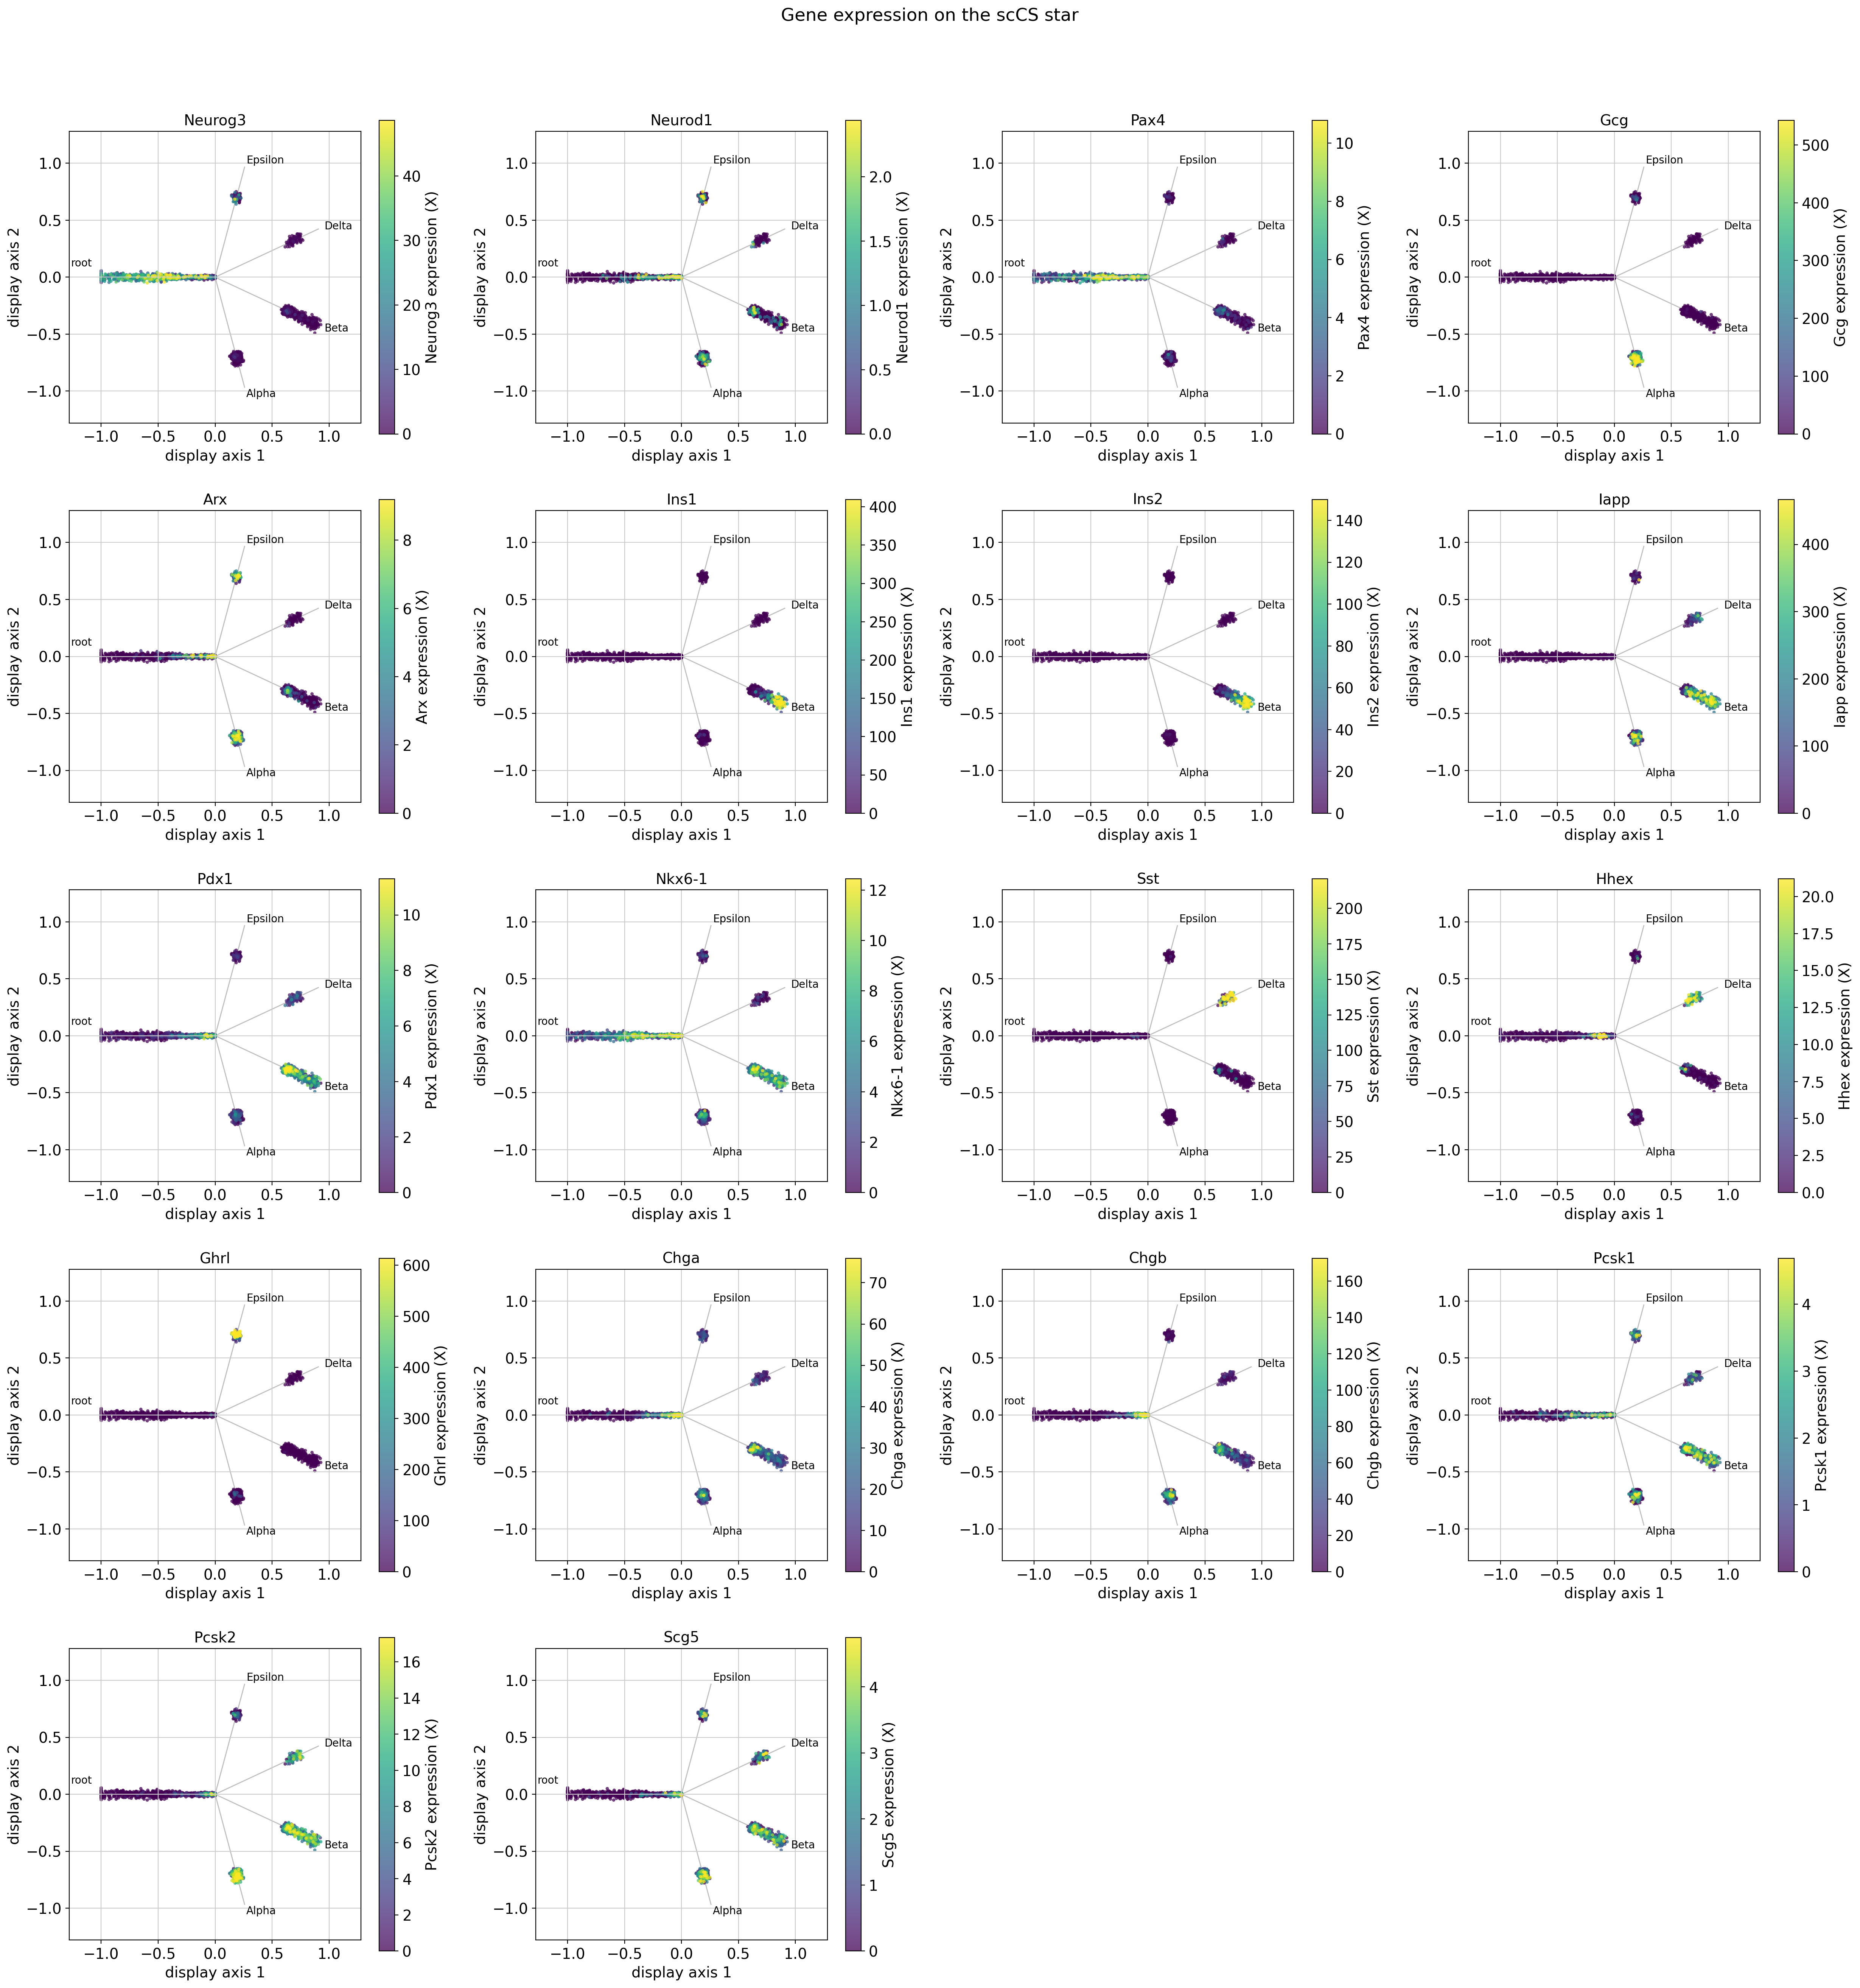

In [9]:
marker_figure = scorer.plot_gene_expression_star(
    markers,
    result,
    ncols=4,
    shared_scale=False,
    terminal_layout="ordering",
)
marker_figure.savefig(
    OUTPUT_DIR / "downstream_marker_expression_stars.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 8. Expression trends along ordering and DFFP quantities

Ordering trends show when a gene changes along the selected developmental
coordinate. CFA and RC trends instead ask whether expression covaries with a
specific future identity or with resolved commitment.

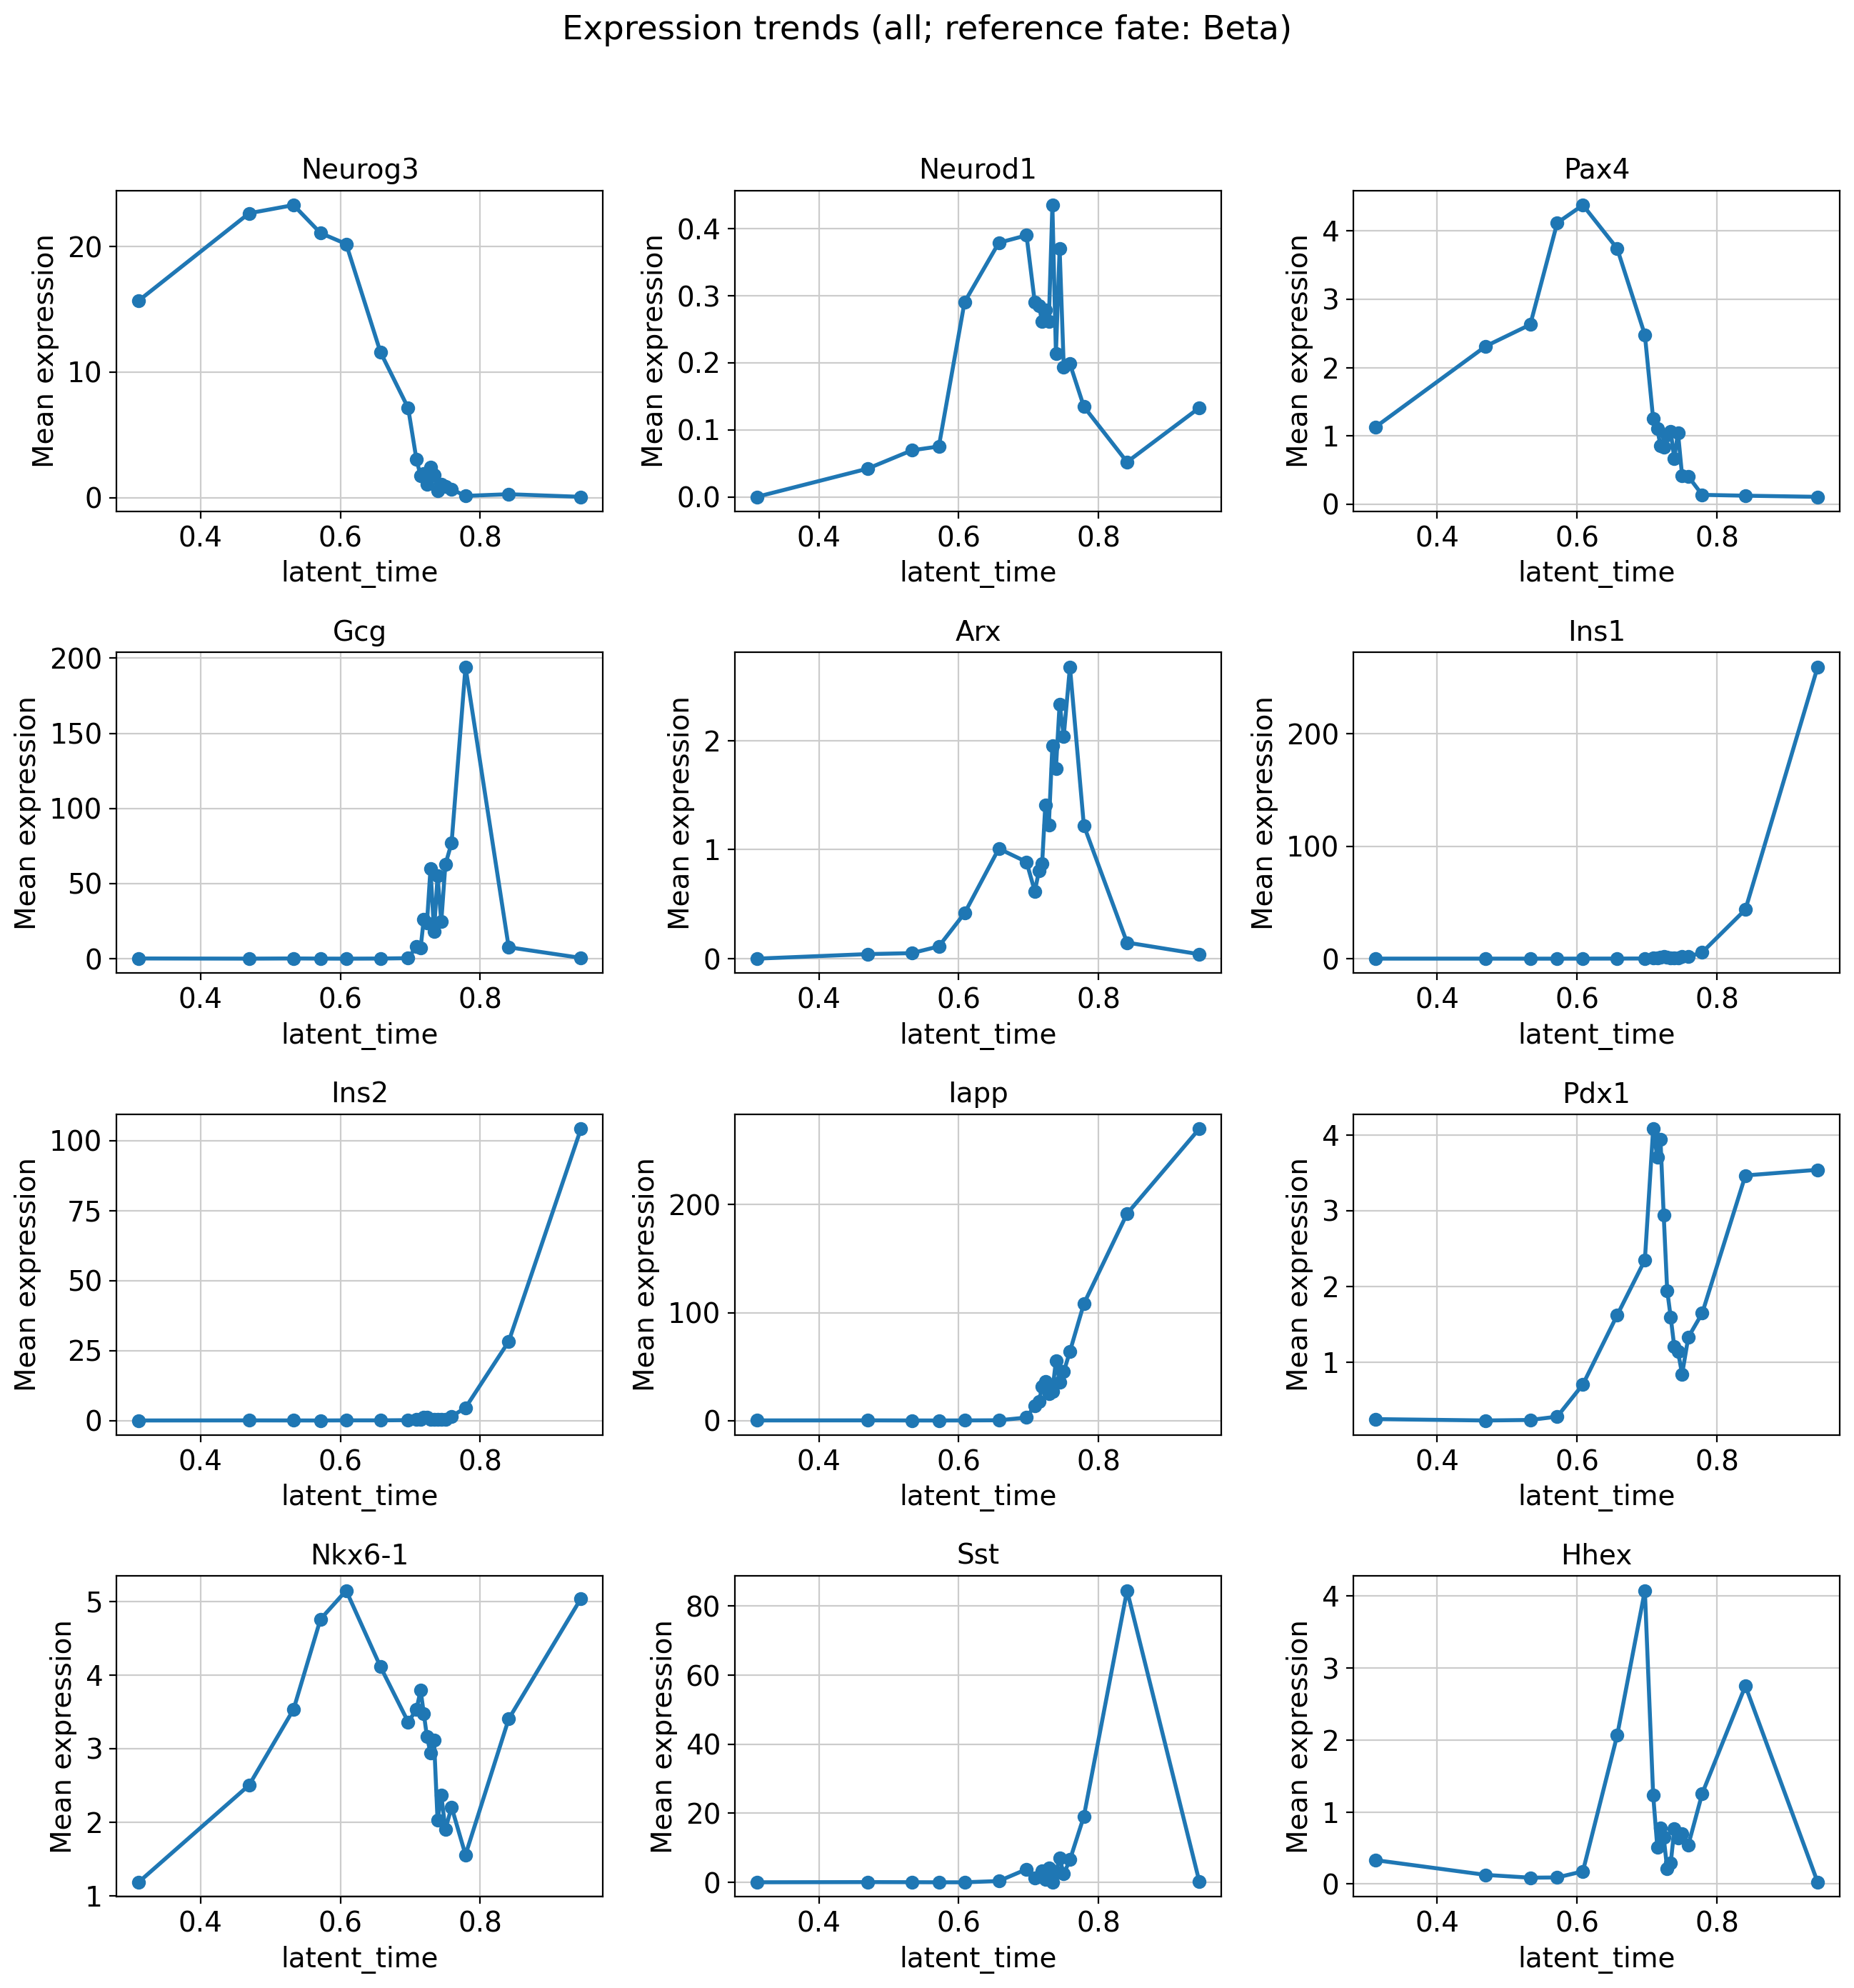

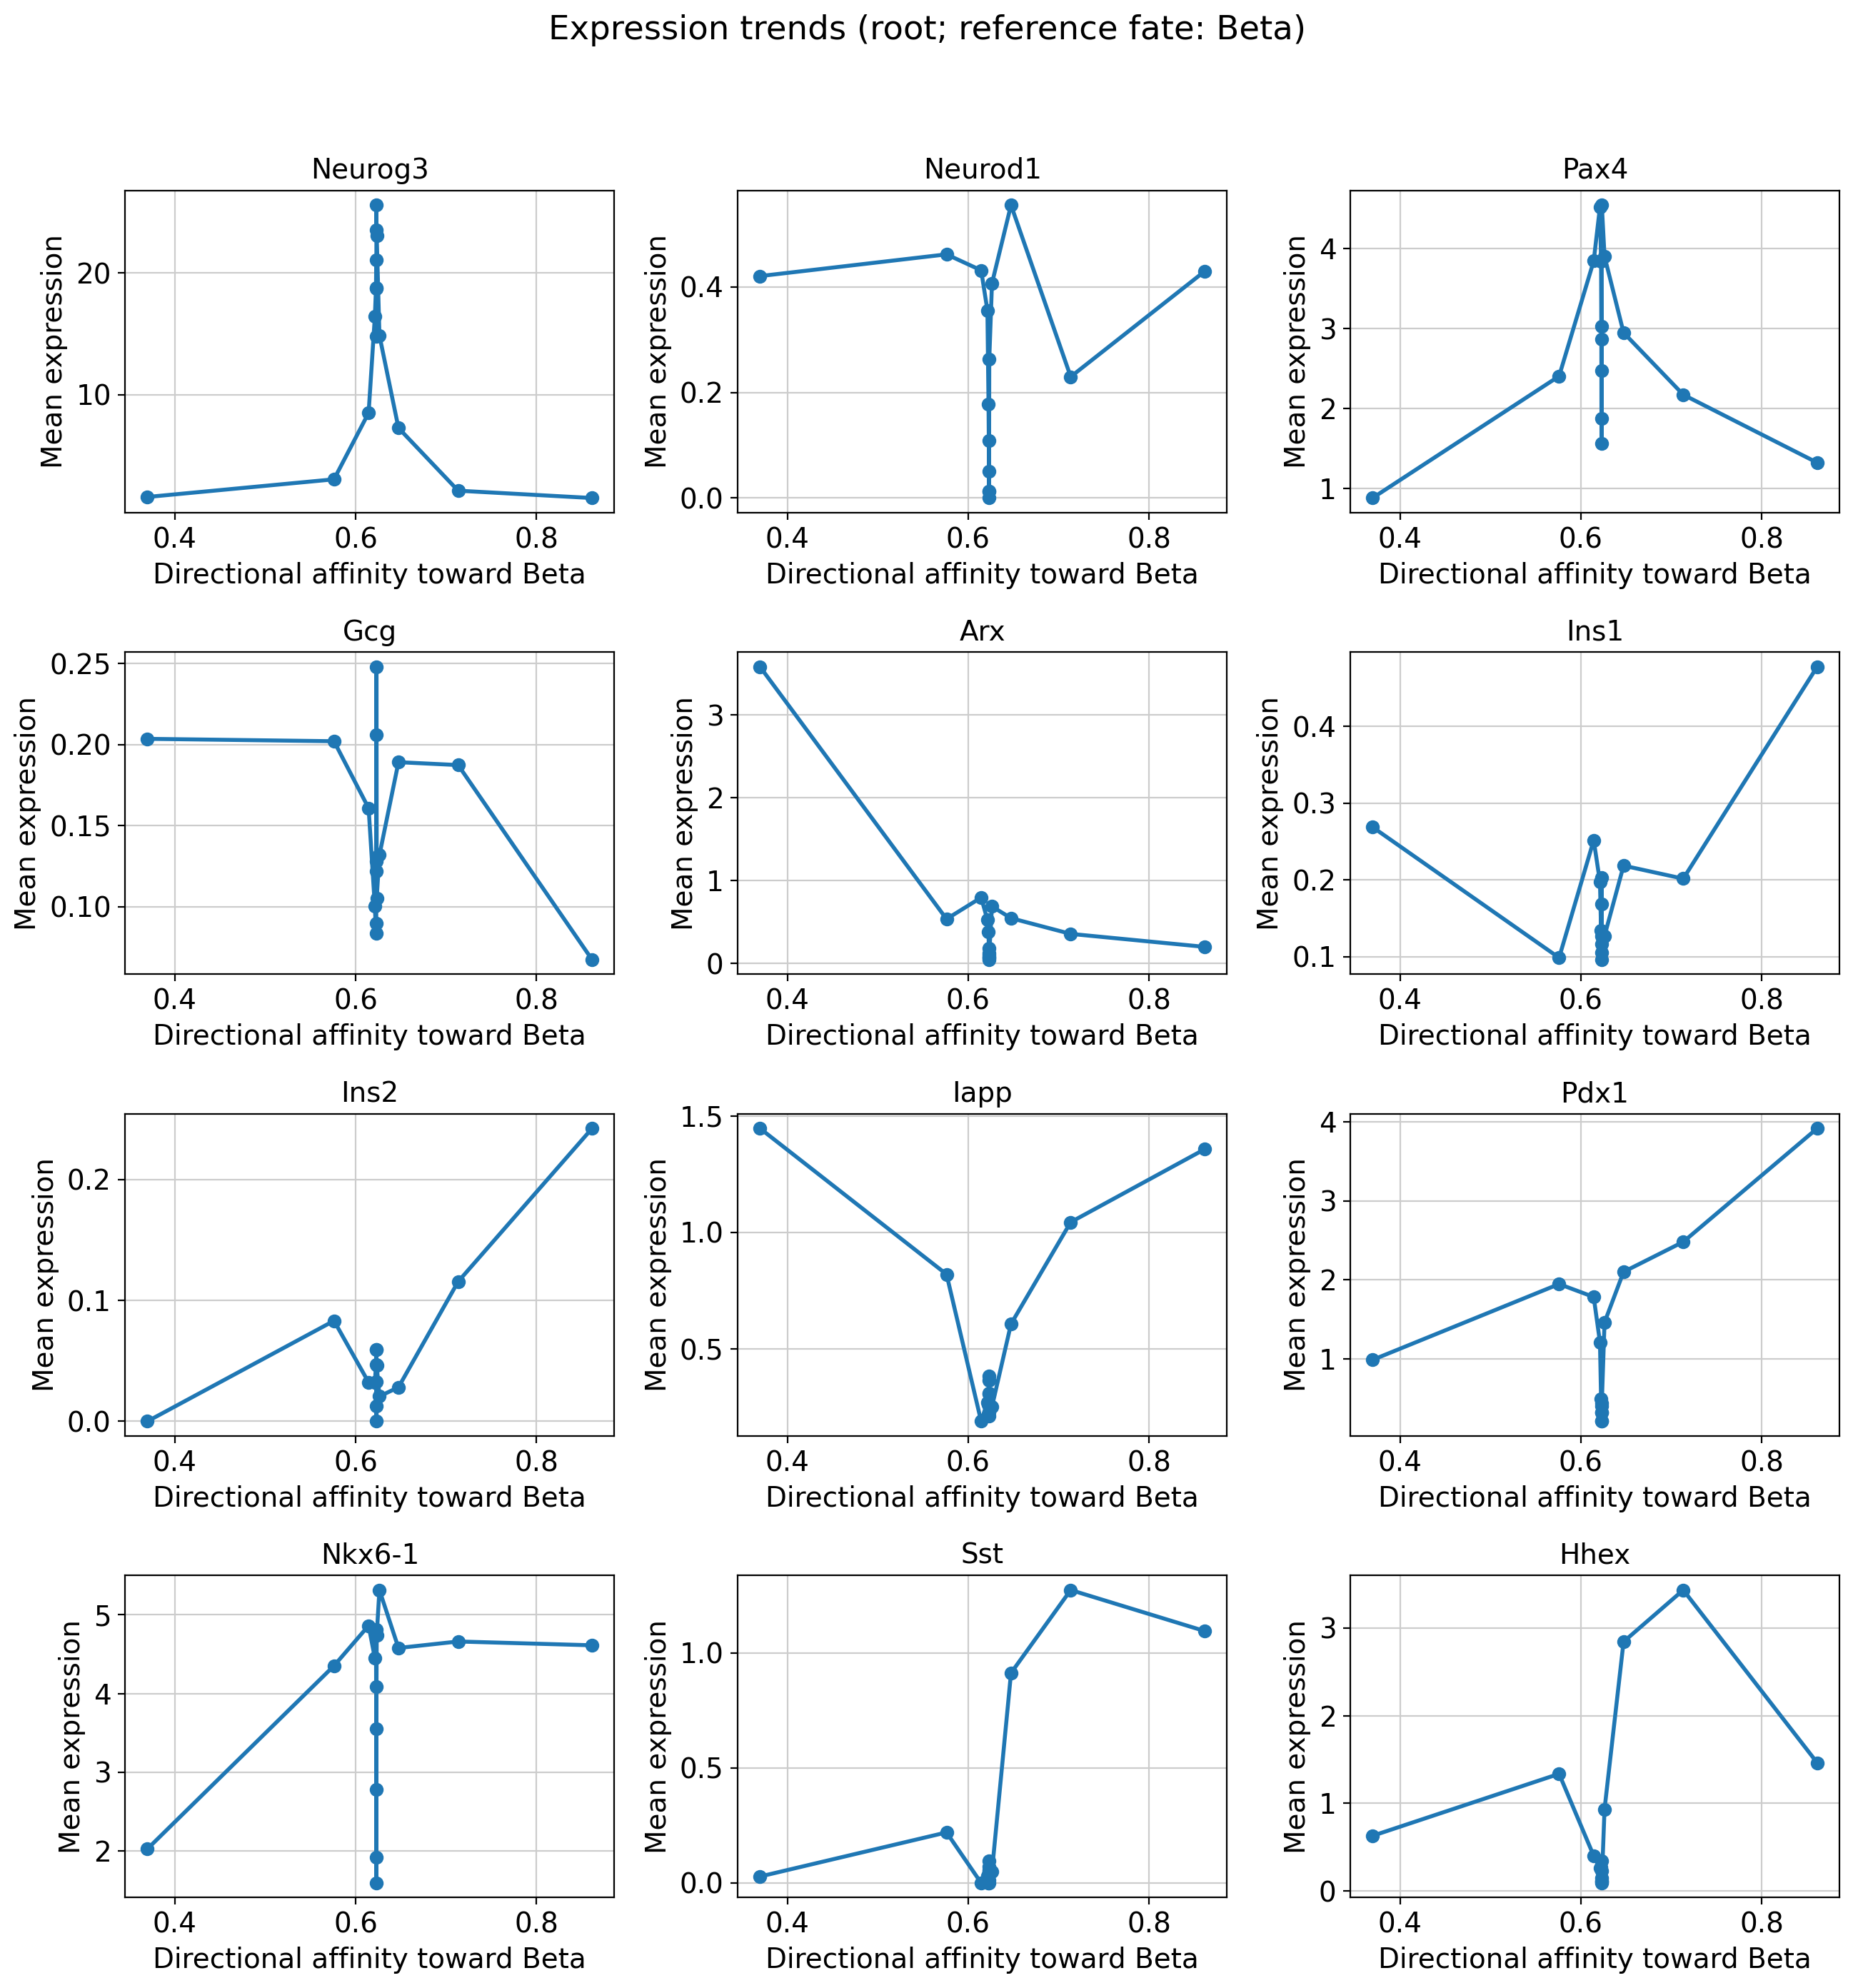

In [10]:
trend_genes = markers[:12]
ordering_trends = scorer.plot_expression_trends(
    trend_genes,
    result,
    x_axis="ordering",
    population="all",
    n_bins=20,
    ncols=3,
)
ordering_trends.savefig(
    OUTPUT_DIR / "expression_trends_ordering.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

beta_trends = scorer.plot_expression_trends(
    trend_genes,
    result,
    fate="Beta",
    x_axis="affinity",
    population="root",
    n_bins=15,
    ncols=3,
)
beta_trends.savefig(
    OUTPUT_DIR / "expression_trends_beta_CFA.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 9. Candidate commitment-associated genes

The public pancreas dataset does not provide independent biological replicates
for this tutorial. Therefore, `cell_exploratory` is used only for candidate
generation and visualization. The resulting p-values must not be presented as
replicate-level evidence.

In [11]:
association = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="cell_exploratory",
    pseudotime_key=ORDERING_KEY,
    min_cells=100,
    min_feature_cells=10,
    min_feature_fraction=0.01,
    n_top_genes=50,
    verbose=True,
)
for fate in FATES:
    print("\n", fate)
    display(association.top(fate, n=20))
association.export(OUTPUT_DIR, prefix="pancreas_CFA_association")


[scCS] Candidate commitment-associated genes: Alpha
        inference_unit=cell_exploratory; matrix=X; n_units=1234; tested_genes=6946
 rank     gene   effect   pvalue_adj  significant
    1   Tmsb4x 0.275744 6.866232e-20         True
    2  Neurog3 0.249886 5.188467e-16         True
    3     Ppib 0.242993 3.842847e-15         True
    4      Mdk 0.242233 4.414893e-15         True
    5     Rps9 0.239684 9.050625e-15         True
    6      Cck 0.234886 2.988312e-14         True
    7     Btg2 0.233772 3.955025e-14         True
    8   Btbd17 0.233522 4.020746e-14         True
    9     Cd63 0.229856 1.163901e-13         True
   10  Igfbpl1 0.225002 4.719493e-13         True
   11    Rps11 0.220966 1.330870e-12         True
   12  Gadd45a 0.218992 2.158346e-12         True
   13     Pax4 0.214899 6.643259e-12         True
   14     Cdk4 0.208052 3.532527e-11         True
   15     Dbn1 0.203733 1.012706e-10         True
   16  Smarcd2 0.202143 1.460725e-10         True
   17     Selm

,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Tmsb4x,0.275744,5.931096e-23,6.866232e-20,26.480909,25.720442,1169,1234,True,0.275744,1
1,Neurog3,0.249886,5.228804e-19,5.188467e-16,13.379286,13.727636,988,1234,True,0.249886,2
2,Ppib,0.242993,4.979215e-18,3.842847e-15,8.263345,5.597094,1201,1234,True,0.242993,3
3,Mdk,0.242233,6.356023e-18,4.414893e-15,15.501658,12.948563,1124,1234,True,0.242233,4
4,Rps9,0.239684,1.433298e-17,9.050625e-15,32.504977,9.654044,1234,1234,True,0.239684,5
5,Cck,0.234886,6.453309e-17,2.988312e-14,20.157887,22.982749,994,1234,True,0.234886,6
6,Btg2,0.233772,9.110337e-17,3.955025e-14,8.378012,5.691946,1196,1234,True,0.233772,7
7,Btbd17,0.233522,9.840581e-17,4.020746e-14,5.285445,5.445983,882,1234,True,0.233522,8
8,Cd63,0.229856,3.016156e-16,1.163901e-13,10.626693,5.767550,1221,1234,True,0.229856,9
9,Igfbpl1,0.225002,1.290964e-15,4.719493e-13,2.379176,3.276287,703,1234,True,0.225002,10



 Beta


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Pcsk2,0.240656,1.052197e-17,3.654280e-14,0.824410,2.119913,285,1234,True,0.240656,1
1,Rbp4,0.224756,1.388129e-15,3.213982e-12,6.374880,17.573840,573,1234,True,0.224756,2
2,Npepl1,0.218365,8.927872e-15,1.550325e-11,1.879040,2.161760,844,1234,True,0.218365,3
3,Pdx1,0.216645,1.458831e-14,2.026609e-11,1.220922,1.919877,586,1234,True,0.216645,4
4,Mnx1,0.215440,2.052819e-14,2.376480e-11,0.251422,0.889925,125,1234,True,0.215440,5
5,Pim2,0.195233,4.674078e-12,4.638021e-09,0.999573,1.959778,460,1234,True,0.195233,6
6,1700086L19Rik,0.187750,3.028669e-11,2.629641e-08,1.625739,3.346094,461,1234,True,0.187750,7
7,Pyy,0.183906,7.680592e-11,5.927710e-08,15.748496,61.305059,631,1234,True,0.183906,8
8,Fxyd6,0.180545,1.705015e-10,1.184303e-07,0.975067,1.746535,455,1234,True,0.180545,9
9,Chgb,0.178527,2.732536e-10,1.725473e-07,26.170255,48.147127,615,1234,True,0.178527,10



 Delta


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Cdkn1a,0.341412,4.921791e-35,3.418676e-31,7.192985,11.485302,930,1234,True,0.341412,1
1,Mboat4,0.338549,1.923454e-34,6.680157e-31,0.244339,1.053657,119,1234,True,0.338549,2
2,Isl1,0.297690,1.187606e-26,2.019228e-23,3.723734,8.049448,438,1234,True,0.297690,3
3,Arx,0.297191,1.453519e-26,2.019228e-23,0.548678,1.612283,209,1234,True,0.297191,4
4,Cd200,0.287990,5.620897e-25,6.507125e-22,0.846095,1.491867,425,1234,True,0.287990,5
5,Peg3,0.269294,6.283696e-22,6.235222e-19,5.624904,5.022496,1143,1234,True,0.269294,6
6,Tm4sf4,0.249135,6.707171e-19,5.823501e-16,3.366878,4.171071,862,1234,True,0.249135,7
7,Peg10,0.233154,1.102107e-16,6.379363e-14,0.182685,0.908079,72,1234,True,0.233154,8
8,Trp53cor1,0.228891,4.037835e-16,2.157446e-13,0.106156,0.414571,95,1234,True,0.228891,9
9,Glud1,0.214502,2.674047e-14,1.092584e-11,3.630171,4.123165,972,1234,True,0.214502,10



 Epsilon


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Cdkn1a,0.309303,9.612805e-29,6.677054e-25,7.192985,11.485302,930,1234,True,0.309303,1
1,Arx,0.303512,1.090822e-27,3.788425e-24,0.548678,1.612283,209,1234,True,0.303512,2
2,Mboat4,0.290981,1.738531e-25,4.025278e-22,0.244339,1.053657,119,1234,True,0.290981,3
3,Tm4sf4,0.237835,2.569547e-17,2.868121e-14,3.366878,4.171071,862,1234,True,0.237835,4
4,Peg3,0.237758,2.632457e-17,2.868121e-14,5.624904,5.022496,1143,1234,True,0.237758,5
5,Glud1,0.237460,2.890418e-17,2.868121e-14,3.630171,4.123165,972,1234,True,0.237460,6
6,Cd200,0.229925,2.953960e-16,1.865291e-13,0.846095,1.491867,425,1234,True,0.229925,7
7,Trp53cor1,0.211789,5.707460e-14,2.642934e-11,0.106156,0.414571,95,1234,True,0.211789,8
8,Muc1,0.208200,1.531472e-13,6.648502e-11,0.439841,0.891349,326,1234,True,0.208200,9
9,Anpep,0.187485,3.231839e-11,1.181492e-08,0.294801,0.849643,224,1234,True,0.187485,10


['tutorial_outputs/pancreas_downstream/pancreas_CFA_association_Alpha.csv',
 'tutorial_outputs/pancreas_downstream/pancreas_CFA_association_Beta.csv',
 'tutorial_outputs/pancreas_downstream/pancreas_CFA_association_Delta.csv',
 'tutorial_outputs/pancreas_downstream/pancreas_CFA_association_Epsilon.csv',
 'tutorial_outputs/pancreas_downstream/pancreas_CFA_association_metadata.json']

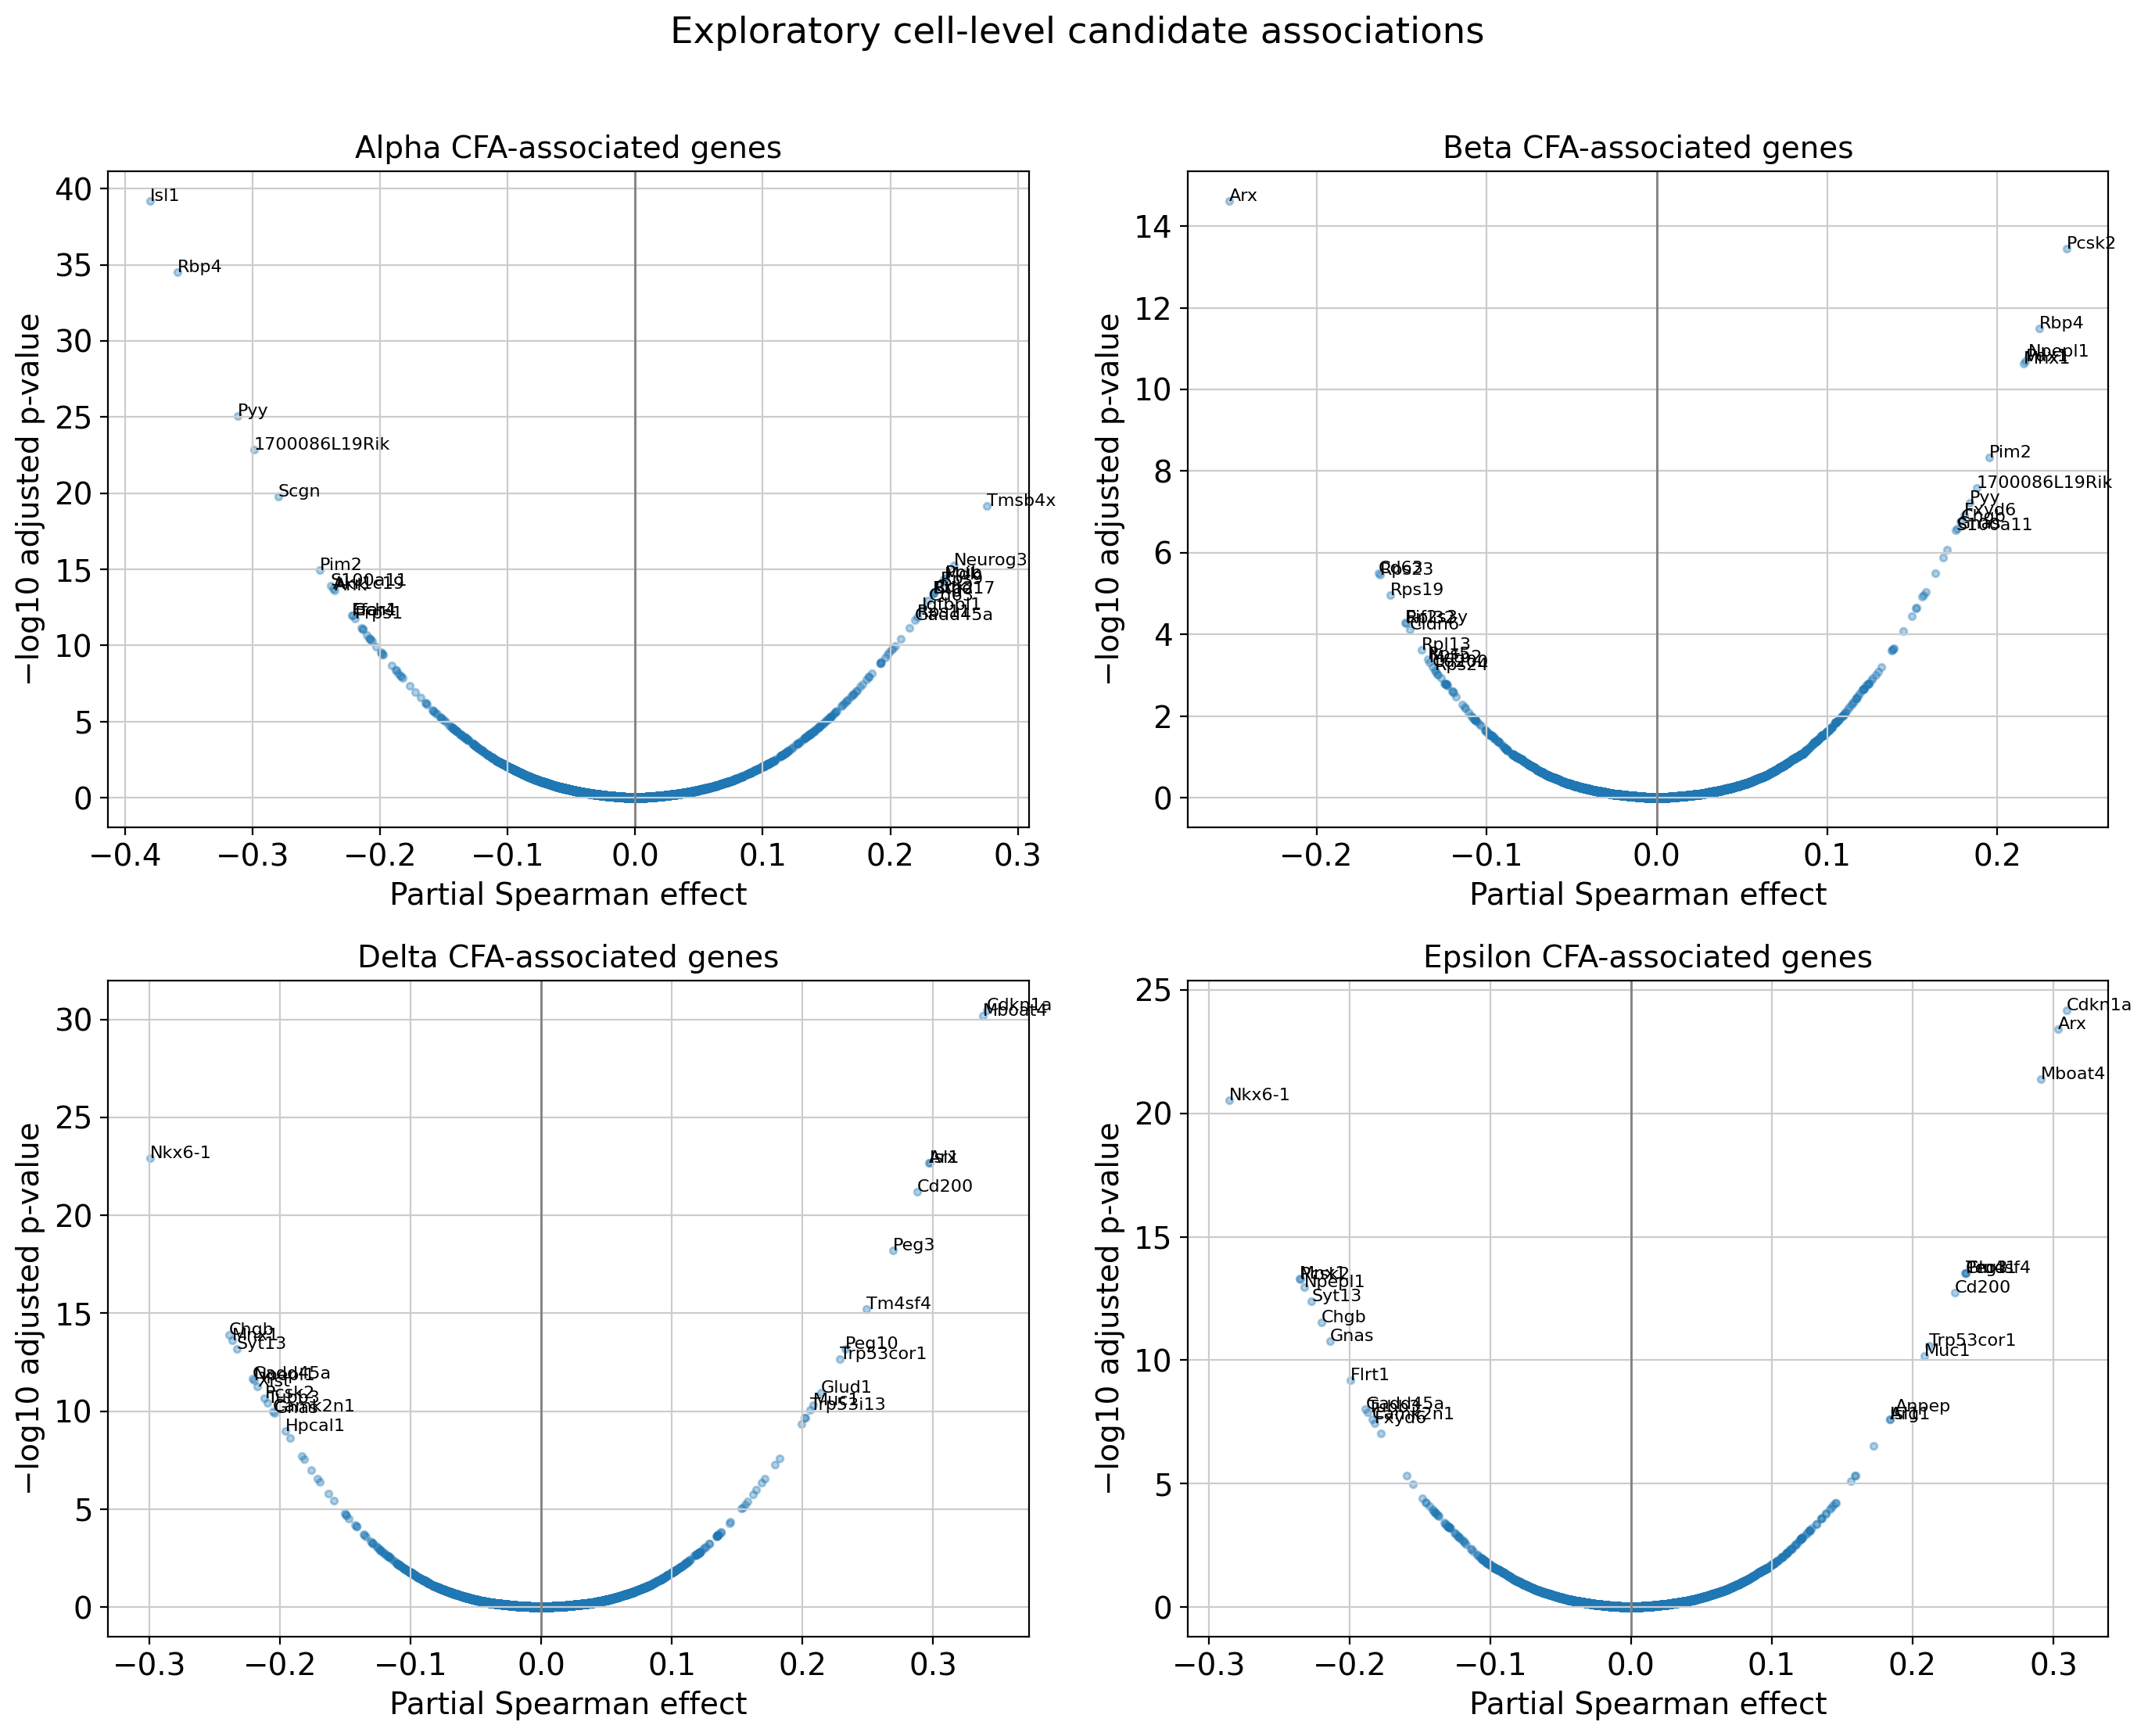

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for axis, fate in zip(axes.ravel(), FATES):
    table = association.tables[fate].copy()
    shown = pd.concat(
        [
            table.nlargest(12, "effect"),
            table.nsmallest(12, "effect"),
        ]
    ).drop_duplicates("gene")
    axis.scatter(
        table["effect"],
        -np.log10(table["pvalue_adj"].clip(lower=1e-300)),
        s=10,
        alpha=0.35,
    )
    for row in shown.itertuples():
        axis.text(
            row.effect,
            -np.log10(max(row.pvalue_adj, 1e-300)),
            row.gene,
            fontsize=8,
        )
    axis.axvline(0, color="0.5", linewidth=1)
    axis.set_title(f"{fate} CFA-associated genes")
    axis.set_xlabel("Partial Spearman effect")
    axis.set_ylabel("−log10 adjusted p-value")
fig.suptitle("Exploratory cell-level candidate associations", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "CFA_association_volcanoes.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Fate markers versus commitment-associated genes

Fate markers compare annotated terminal cells with the root. Commitment
associations are calculated within the selected analysis population and can
identify genes varying before terminal identity is fully established.

In [13]:
fate_markers = scorer.get_fate_markers(
    method="wilcoxon",
    fdr_threshold=0.05,
    logfc_threshold=0.25,
    min_cells=10,
    verbose=True,
)
for fate, table in fate_markers.items():
    table.to_csv(OUTPUT_DIR / f"fate_markers_{fate}.csv", index=False)
    print("\n", fate)
    display(table.head(20))

ranking genes
    finished (0:00:00)

[scCS] Fate markers: Alpha vs root; significant=2275
 rank    gene  logfoldchange    pvalue_adj
    1     Pyy     233.343811 1.051944e-160
    2     Gcg     209.721115  1.613987e-83
    3    Iapp     100.156334 3.267432e-138
    4     Ttr      69.962547 3.499607e-146
    5    Gnas      51.120472 2.153794e-130
    6    Rbp4      43.370220 7.934233e-127
    7   Hpgds      26.723766  1.768276e-02
    8     Tnr      26.722797  1.221011e-02
   21  Tmem27      18.768389 3.627194e-200
   22 Slc38a5      18.712347 1.562776e-124
   23  Pcsk1n      17.453619 6.113637e-142
   24     Cpe      13.869763 1.434444e-125
   25 Slc25a5      12.463739  3.970180e-52
   26    Gast      11.470784  3.008741e-52
   27   Pcsk2       9.351954 1.479988e-117
   28    Gpx3       8.338355 3.580264e-131
   29   Meis2       8.270338 1.147131e-145
   30   Peg10       7.708434  2.012753e-97
   31     Ppy       7.698100  3.638924e-25
   32    Isl1       7.264405  2.414985e-71
rankin

,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Pyy,27.298784,233.343811,4.384929e-164,1.051944e-160,0.968815,True,terminal_annotation_marker_vs_root,1
1,Gcg,19.606232,209.721115,1.367976e-85,1.613987e-83,0.656965,True,terminal_annotation_marker_vs_root,2
2,Iapp,25.275759,100.156334,5.901990e-141,3.267432e-138,0.854470,True,terminal_annotation_marker_vs_root,3
3,Ttr,26.014395,69.962547,3.403814e-149,3.499607e-146,1.000000,True,terminal_annotation_marker_vs_root,4
4,Gnas,24.545862,51.120472,4.788205e-133,2.153794e-130,1.000000,True,terminal_annotation_marker_vs_root,5
5,Rbp4,24.200369,43.370220,2.204872e-129,7.934233e-127,0.962578,True,terminal_annotation_marker_vs_root,6
6,Hpgds,2.812783,26.723766,4.911470e-03,1.768276e-02,0.087318,True,terminal_annotation_marker_vs_root,7
7,Tnr,2.946726,26.722797,3.211580e-03,1.221011e-02,0.091476,True,terminal_annotation_marker_vs_root,8
8,Dpp10,1.406392,25.546453,1.596078e-01,3.284975e-01,0.043659,False,terminal_annotation_marker_vs_root,9
9,Kcnip4,0.803652,24.992832,4.215977e-01,6.472897e-01,0.024948,False,terminal_annotation_marker_vs_root,10



 Beta


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Iapp,31.406631,186.131287,1.642611e-216,1.182187e-212,0.944162,True,terminal_annotation_marker_vs_root,1
1,Pyy,27.752472,162.698456,1.626816e-169,1.170819e-166,0.962775,True,terminal_annotation_marker_vs_root,2
2,Ins1,17.335060,99.442055,2.557974e-67,1.314981e-65,0.582064,True,terminal_annotation_marker_vs_root,3
3,Rbp4,30.064129,50.622169,1.427144e-198,2.567789e-195,0.996616,True,terminal_annotation_marker_vs_root,4
4,Ins2,20.527544,48.017612,1.221961e-93,9.881409e-92,0.610829,True,terminal_annotation_marker_vs_root,5
5,Gnas,27.004543,42.680595,1.307045e-160,7.839004e-158,1.000000,True,terminal_annotation_marker_vs_root,6
6,Nnat,25.606888,42.575066,1.278533e-144,3.539079e-142,0.825719,True,terminal_annotation_marker_vs_root,7
7,Cdh23,1.639956,25.650280,1.010144e-01,2.167563e-01,0.047377,False,terminal_annotation_marker_vs_root,8
8,Ptprz1,1.815665,25.624140,6.942174e-02,1.598811e-01,0.052453,False,terminal_annotation_marker_vs_root,9
9,Tnr,1.698526,25.451895,8.940862e-02,1.963606e-01,0.049069,False,terminal_annotation_marker_vs_root,10



 Delta


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Pyy,13.587565,507.735718,4.746092e-42,1.707881e-38,1.000000,True,terminal_annotation_marker_vs_root,1
1,Sst,12.178400,333.075989,4.051542e-34,3.239883e-31,0.871429,True,terminal_annotation_marker_vs_root,2
2,Rbp4,13.927866,204.135147,4.289831e-44,3.087391e-40,1.000000,True,terminal_annotation_marker_vs_root,3
3,Iapp,13.506161,103.372108,1.438297e-41,3.450474e-38,0.985714,True,terminal_annotation_marker_vs_root,4
4,Ptprz1,3.623568,28.902637,2.905666e-04,4.037080e-03,0.257143,True,terminal_annotation_marker_vs_root,5
5,Cntn1,1.409165,27.251200,1.587863e-01,5.970662e-01,0.100000,False,terminal_annotation_marker_vs_root,6
6,Hpgds,1.207856,26.802217,2.271026e-01,7.303207e-01,0.085714,False,terminal_annotation_marker_vs_root,7
7,Tnr,1.409165,26.669956,1.587863e-01,5.970662e-01,0.100000,False,terminal_annotation_marker_vs_root,8
8,Dpp10,0.805237,26.087811,4.206827e-01,9.597528e-01,0.057143,False,terminal_annotation_marker_vs_root,9
9,Nlgn1,0.201309,24.924381,8.404567e-01,1.000000e+00,0.014286,False,terminal_annotation_marker_vs_root,10



 Epsilon


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Ghrl,19.460413,496.845154,2.378630e-84,1.711900e-80,1.000000,True,terminal_annotation_marker_vs_root,1
1,Pyy,12.460391,105.076279,1.227675e-35,1.520765e-33,0.873239,True,terminal_annotation_marker_vs_root,2
2,Rbp4,17.321424,84.230026,3.242339e-67,1.166756e-63,0.992958,True,terminal_annotation_marker_vs_root,3
3,Lrpprc,12.808173,26.874617,1.475683e-37,2.212602e-35,0.873239,True,terminal_annotation_marker_vs_root,4
4,Tnr,1.788753,26.569187,7.365458e-02,2.781175e-01,0.091549,False,terminal_annotation_marker_vs_root,5
5,Hpgds,1.375964,26.106819,1.688328e-01,4.925373e-01,0.070423,False,terminal_annotation_marker_vs_root,6
6,Sorcs1,0.550386,25.018215,5.820549e-01,9.302797e-01,0.028169,False,terminal_annotation_marker_vs_root,7
7,Cntn1,0.412789,24.271919,6.797611e-01,9.705308e-01,0.021127,False,terminal_annotation_marker_vs_root,8
8,Nlgn1,0.412789,24.233652,6.797611e-01,9.705308e-01,0.021127,False,terminal_annotation_marker_vs_root,9
9,Isl1,16.356800,23.863163,3.890428e-60,5.599882e-57,0.992958,True,terminal_annotation_marker_vs_root,10


In [14]:
overlap_rows = []
for fate in FATES:
    association_genes = set(association.top(fate, n=100, positive_only=True)["gene"])
    marker_genes = set(fate_markers[fate].head(100)["gene"])
    overlap_rows.append(
        {
            "fate": fate,
            "top_association_genes": len(association_genes),
            "top_marker_genes": len(marker_genes),
            "overlap": len(association_genes & marker_genes),
            "overlap_genes": ", ".join(sorted(association_genes & marker_genes)),
        }
    )
overlap_table = pd.DataFrame(overlap_rows)
display(overlap_table)
overlap_table.to_csv(OUTPUT_DIR / "association_marker_overlap.csv", index=False)

,fate,top_association_genes,top_marker_genes,overlap,overlap_genes
0,Alpha,100,100,0,
1,Beta,100,100,20,"1700086L19Rik, Chga, Cpe, Dlk1, Dynll1, Fam159..."
2,Delta,100,100,15,"Arg1, Bsg, Cd200, Cd24a, Fam183b, Ghr, Gria2, ..."
3,Epsilon,100,100,22,"Alcam, Anpep, Arg1, Arx, Bsg, Cdkn1a, Cpn1, En..."


## 11. Reproducible local enrichment

The tutorial uses a small local mouse endocrine gene-set mapping so the analysis
is deterministic and does not depend on a changing remote database. For a
publication, replace it with a versioned GMT file and an assay-specific
background.

In [15]:
local_gene_sets = {
    "endocrine_progenitor_program": {"Neurog3", "Neurod1", "Insm1", "Pax4", "Pax6"},
    "insulin_secretory_program": {"Ins1", "Ins2", "Iapp", "Pcsk1", "Pcsk2", "Chga", "Chgb"},
    "alpha_identity_program": {"Gcg", "Mafb", "Arx", "Ttr", "Slc7a2"},
    "beta_identity_program": {"Ins1", "Ins2", "Pdx1", "Nkx6-1", "Mafa", "Iapp"},
    "delta_identity_program": {"Sst", "Hhex", "Ghsr", "Rbp4", "Col25a1"},
    "epsilon_identity_program": {"Ghrl", "Irx2", "Tspan8", "Slc18a1", "Fev"},
    "neuroendocrine_granules": {"Chga", "Chgb", "Scg2", "Scg3", "Scg5", "Cpe"},
}
present = set(map(str, adata.var_names))
local_gene_sets = {
    term: sorted(set(genes) & present)
    for term, genes in local_gene_sets.items()
}
display(pd.Series({term: len(genes) for term, genes in local_gene_sets.items()}, name="n_genes"))

endocrine_progenitor_program    4
insulin_secretory_program       7
alpha_identity_program          4
beta_identity_program           5
delta_identity_program          3
epsilon_identity_program        4
neuroendocrine_granules         5
Name: n_genes, dtype: int64

[scCS] Enrichment Alpha: query_genes=150, significant_terms=1
[scCS] Enrichment Beta: query_genes=150, significant_terms=6
[scCS] Enrichment Delta: query_genes=150, significant_terms=1
[scCS] Enrichment Epsilon: query_genes=150, significant_terms=1


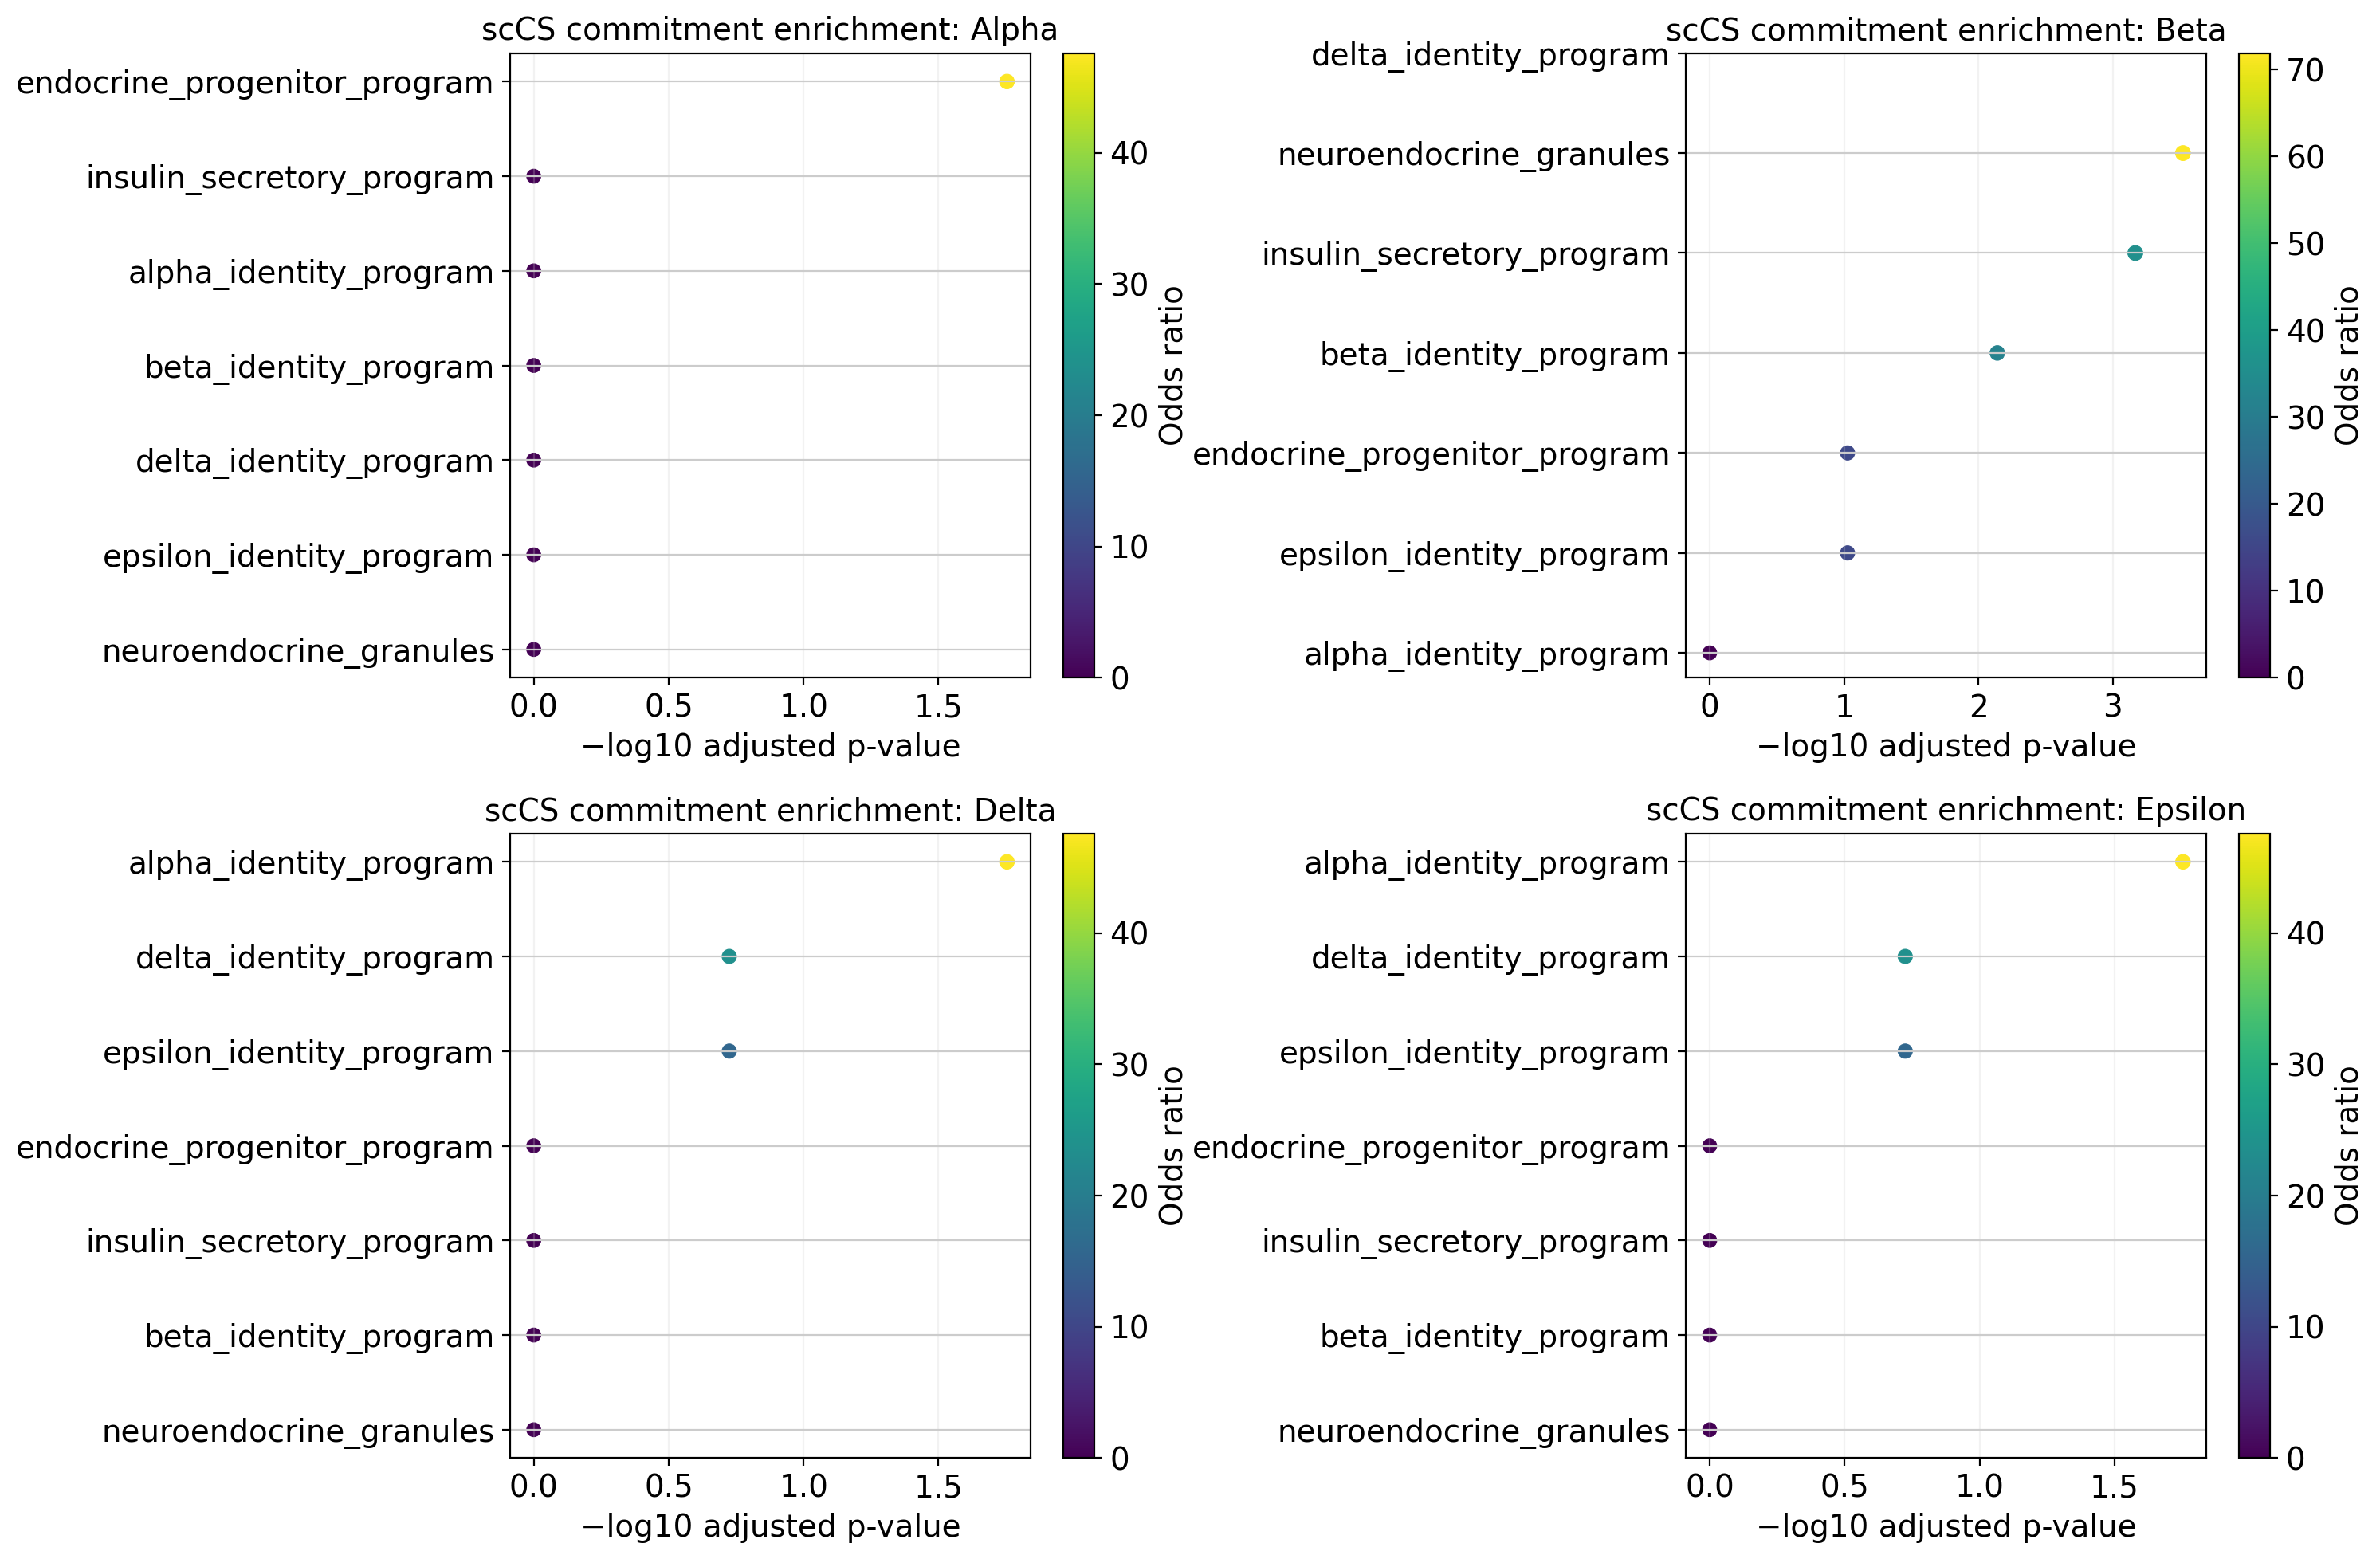

In [16]:
enrichment = scCS.run_commitment_enrichment(
    association,
    gene_sets=local_gene_sets,
    background=adata.var_names,
    direction="positive",
    effect_threshold=0.05,
    significant_only=False,
    max_genes=150,
    min_query_genes=3,
    min_set_size=3,
    fdr_threshold=0.10,
    verbose=True,
)
enrichment.export(OUTPUT_DIR, prefix="pancreas_local_enrichment")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for axis, fate in zip(axes.ravel(), FATES):
    scCS.plot_enrichment_dotplot(
        enrichment,
        fate,
        n_terms=10,
        significant_only=False,
        ax=axis,
    )
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "local_enrichment_dotplots.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Subset summaries: early, middle, and late root

Subset comparisons can show how fate composition changes along the incoming
path. They remain descriptive unless subsets correspond to independent
biological replicate units.

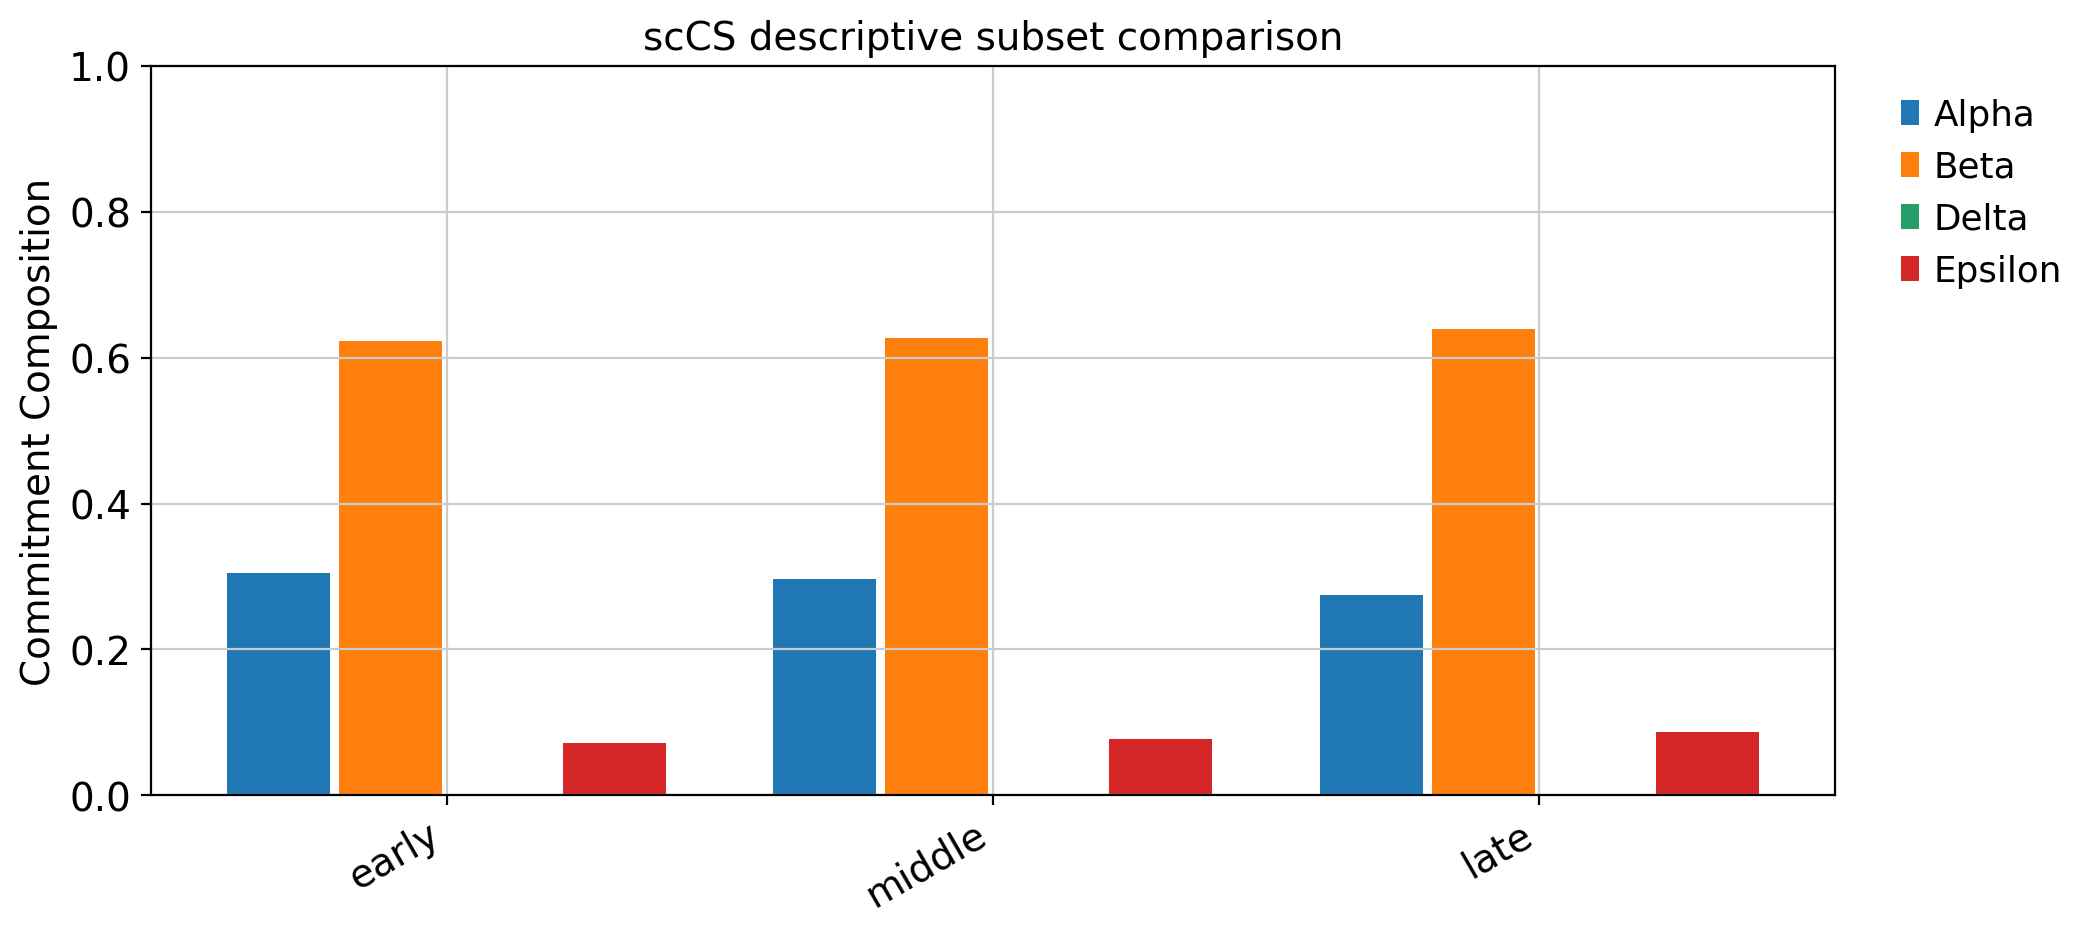

In [17]:
root_ids = result.cell_ids[result.root_mask]
root_ordering = pd.Series(
    adata.obs.loc[root_ids, ORDERING_KEY].to_numpy(float),
    index=root_ids,
)
third = pd.qcut(
    root_ordering.rank(method="first"),
    q=3,
    labels=["early", "middle", "late"],
)
subset_summaries = {}
for label in ["early", "middle", "late"]:
    mask = result.root_mask.copy()
    mask[result.root_mask] = third.to_numpy() == label
    subset_summaries[label] = result.summarize(mask)

subset_figure = scorer.plot_subset_comparison(
    subset_summaries,
    metric="commitment_composition",
)
subset_figure.savefig(
    OUTPUT_DIR / "root_ordering_thirds_composition.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 13. Replicate-aware template for a real study

For a real multi-sample dataset, rerun the association with genuine biological
replicate metadata:

```python
association_replicate = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="replicate",
    replicate_key="sample_id",
    condition_key="condition",
    pseudotime_key=ORDERING_KEY,
    min_replicates=6,
    min_cells_per_replicate=5,
)
```

Do not construct pseudo-replicates for biological inference.

## 14. Export the complete downstream record

In [18]:
summary_table.to_csv(OUTPUT_DIR / "cell_level_DFFP_metrics.csv", index=False)
adata.write_h5ad(OUTPUT_DIR / "pancreas_downstream_analysis.h5ad")

metadata = {
    "scoring_method": "Discounted Future-Fate Propagation",
    "scoring_mode": "future_fate",
    "velocity_model": "dynamical",
    "ordering_key": ORDERING_KEY,
    "effective_horizon": FUTURE_OPTIONS["effective_horizon"],
    "anchor_quantile": FUTURE_OPTIONS["anchor_quantile"],
    "association_scope": "cell_exploratory_candidate_generation",
    "enrichment_source": "local_in_notebook_mapping",
}
pd.Series(metadata).to_json(
    OUTPUT_DIR / "downstream_metadata.json",
    indent=2,
)
print("Outputs written to", OUTPUT_DIR.resolve())

Outputs written to /home/emil/notebooks/08-tutorials/tutorial_outputs/pancreas_downstream


## Interpretation checklist

- DFFP must be accepted before downstream screening.
- Marker expression, commitment association, and terminal markers answer
  different questions.
- Cell-level association is exploratory without biological replicates.
- Local gene sets and the tested-gene background should be versioned.
- Enrichment supports interpretation; it does not establish causal regulation.